# 03 Conjetura de Collatz

En este notebook exploraremos uno de los problemas abiertos mas famosos de la matematica
usando pocas lineas de Python.

La regla es simple: dado un numero entero positivo $n$,
- si $n$ es **par**, lo dividimos por 2,
- si $n$ es **impar**, lo multiplicamos por 3 y le sumamos 1.

Repetimos hasta llegar a 1. La **Conjetura de Collatz** (1937) dice que
esto siempre ocurre, sin importar el valor inicial. Nadie ha podido demostrarlo.

## Definiciones simples

- **Secuencia (trayectoria)**: lista ordenada de valores que genera la regla.
- **Iteracion**: aplicar la misma regla una y otra vez.
- **Conjetura**: afirmacion que se cree verdadera pero no se ha demostrado.
- **Tiempo de vuelo**: cantidad de pasos para llegar a 1.
- **Altitud maxima**: valor mas grande alcanzado en la trayectoria.

In [1]:
import matplotlib.pyplot as plt

## La funcion de Collatz

Definimos una funcion que recibe un numero entero positivo y devuelve
la trayectoria completa hasta llegar a 1.

In [2]:
def collatz(n):
    """Genera la trayectoria de Collatz partiendo desde n."""
    trayectoria = [n]
    while n != 1:
        if n % 2 == 0:
            n = n // 2
        else:
            n = 3 * n + 1
        trayectoria.append(n)
    return trayectoria

## Primeros ejemplos

Probemos con numeros pequenos para ver como funciona la regla.

In [3]:
for n0 in [6, 7, 12, 19]:
    tray = collatz(n0)
    print(f"n = {n0:>3}  |  pasos: {len(tray)-1:>3}  |  maximo: {max(tray):>5}  |  trayectoria: {tray}")

n =   6  |  pasos:   8  |  maximo:    16  |  trayectoria: [6, 3, 10, 5, 16, 8, 4, 2, 1]
n =   7  |  pasos:  16  |  maximo:    52  |  trayectoria: [7, 22, 11, 34, 17, 52, 26, 13, 40, 20, 10, 5, 16, 8, 4, 2, 1]
n =  12  |  pasos:   9  |  maximo:    16  |  trayectoria: [12, 6, 3, 10, 5, 16, 8, 4, 2, 1]
n =  19  |  pasos:  20  |  maximo:    88  |  trayectoria: [19, 58, 29, 88, 44, 22, 11, 34, 17, 52, 26, 13, 40, 20, 10, 5, 16, 8, 4, 2, 1]


## El caso sorprendente: $n = 27$

El numero 27 es pequeno, pero su trayectoria es enorme.
Veamos cuantos pasos necesita y que tan alto llega.

In [4]:
tray_27 = collatz(27)
print(f"Inicio: 27")
print(f"Pasos para llegar a 1: {len(tray_27) - 1}")
print(f"Maximo alcanzado: {max(tray_27)}")
print(f"Ultimos 10 valores: {tray_27[-10:]}")

Inicio: 27
Pasos para llegar a 1: 111
Maximo alcanzado: 9232
Ultimos 10 valores: [80, 40, 20, 10, 5, 16, 8, 4, 2, 1]


## Visualizacion de trayectorias

Graficamos varias trayectorias para comparar.
Observar como numeros cercanos pueden tener comportamientos muy distintos.

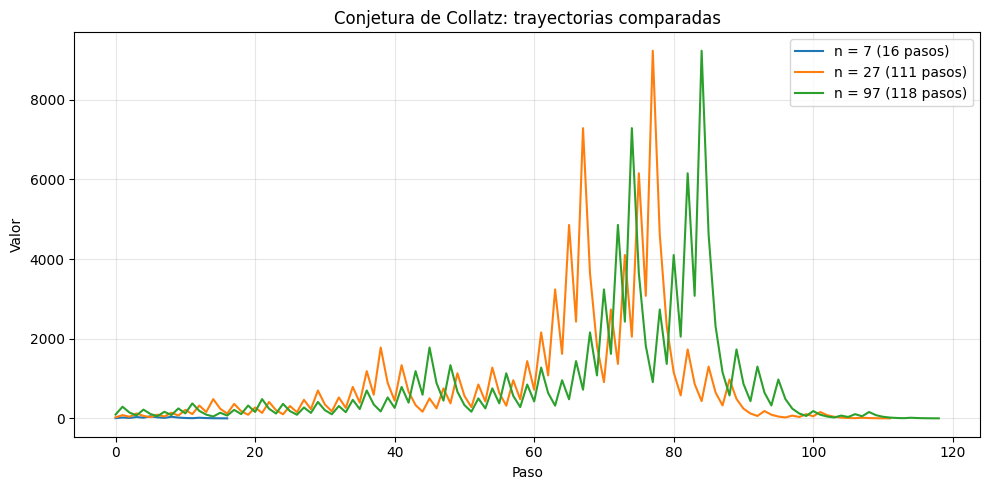

In [5]:
plt.figure(figsize=(10, 5))

for n0 in [7, 27, 97]:
    tray = collatz(n0)
    plt.plot(tray, label=f"n = {n0} ({len(tray)-1} pasos)", linewidth=1.5)

plt.xlabel("Paso")
plt.ylabel("Valor")
plt.title("Conjetura de Collatz: trayectorias comparadas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Tiempo de vuelo para $n = 1, 2, \ldots, 200$

Calculamos cuantos pasos necesita cada numero del 1 al 200
y lo graficamos. Esto muestra que no hay un patron obvio.

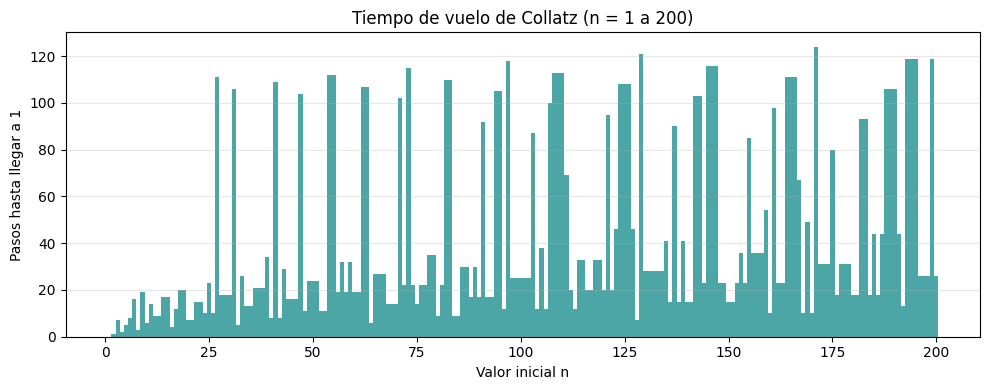

El numero con mas pasos entre 1 y 200 es n = 171 con 124 pasos.


In [6]:
rango = range(1, 201)
pasos = [len(collatz(n)) - 1 for n in rango]

plt.figure(figsize=(10, 4))
plt.bar(rango, pasos, color="teal", alpha=0.7, width=1.0)
plt.xlabel("Valor inicial n")
plt.ylabel("Pasos hasta llegar a 1")
plt.title("Tiempo de vuelo de Collatz (n = 1 a 200)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

n_max = max(rango, key=lambda n: len(collatz(n)))
print(f"El numero con mas pasos entre 1 y 200 es n = {n_max} con {len(collatz(n_max))-1} pasos.")

## Preguntas para discutir

1. Por que el numero 27 tiene una trayectoria tan larga si es tan pequeno?
2. Hay algun patron visible en el grafico de tiempo de vuelo?
3. Si la conjetura fuera falsa, que significaria? (existiria un $n$ que nunca llega a 1)
4. Que diferencia hay entre *verificar* computacionalmente y *demostrar* matematicamente?

## Desafio

Modifica la celda siguiente para encontrar el numero $n \le 1000$
con la trayectoria mas larga. Cual es su tiempo de vuelo y su altitud maxima?

In [7]:
# Desafio: completar este codigo
# Pista: puedes usar max() con una funcion key,
# o simplemente un bucle for que vaya guardando el mejor resultado.

# mejor_n = ???
# mejor_pasos = ???
# print(f"El n con mas pasos hasta 1000 es {mejor_n} con {mejor_pasos} pasos.")